In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import KFold, StratifiedKFold
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
import math
from xgboost import XGBRegressor

In [2]:
import sys
print(sys.executable)

/opt/miniconda3/envs/my-rdkit-env/bin/python


In [3]:
import sys
!{sys.executable} -m pip install openbabel-wheel

In [4]:
# Reading HSP and SMILES data
gpHSP_data = pd.read_csv(r'/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')

mol_smiles = gpHSP_data['SMILES']
hansen_d = gpHSP_data['hansen_d']
hansen_p = gpHSP_data['hansen_p']
hansen_h = gpHSP_data['hansen_h']
mol_number = gpHSP_data['number']
mol_name = gpHSP_data['Molecule']

# calculate total sobubility from HSP
hansen_total = np.sqrt((hansen_d*hansen_d + hansen_p*hansen_p + hansen_h*hansen_h))

In [5]:
# generate fingeprints: Morgan fingerprint with radius 8 with nBits 2048
fps = [AllChem.GetMorganFingerprintAsBitVect(Chem.MolFromSmiles(x), 8, nBits=2048) for x in gpHSP_data['SMILES']]
#convert fps into numpy array
np_fps = np.asarray(fps)
np_fps.shape

# generate MACCS fingerprints
#maccs_fps = [MACCSkeys.GenMACCSKeys (Chem.MolFromSmiles(x)) for x in gpHSP_data['smiles']]

[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerator
[03:58:33] DEPRECATION WARNING: please use MorganGenerat

(1183, 2048)

Fold:1, Train set: 985, Test set:198
MAE  : 0.6141
RMSE : 0.8445
R2   : 0.7602


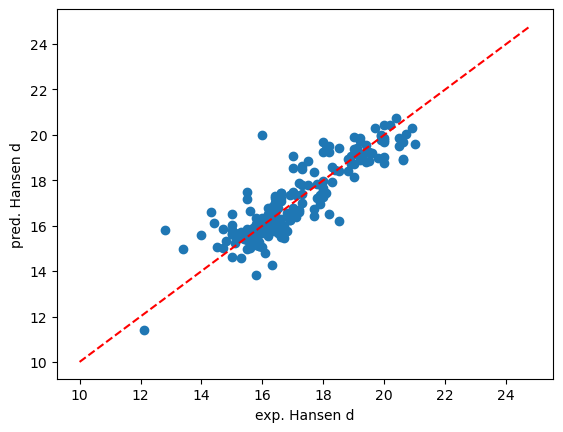

Fold:2, Train set: 986, Test set:197
MAE  : 0.6711
RMSE : 0.9555
R2   : 0.6837


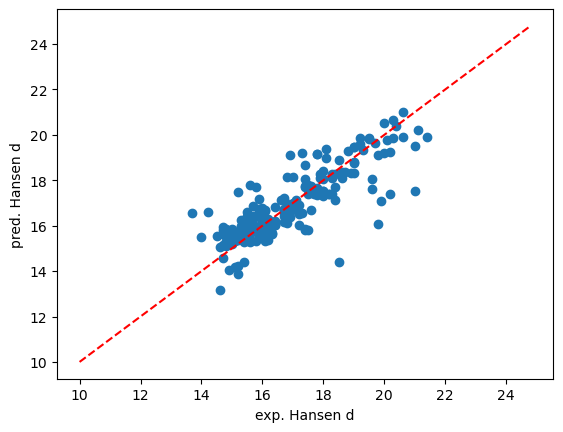

Fold:3, Train set: 986, Test set:197
MAE  : 0.6189
RMSE : 0.8983
R2   : 0.7479


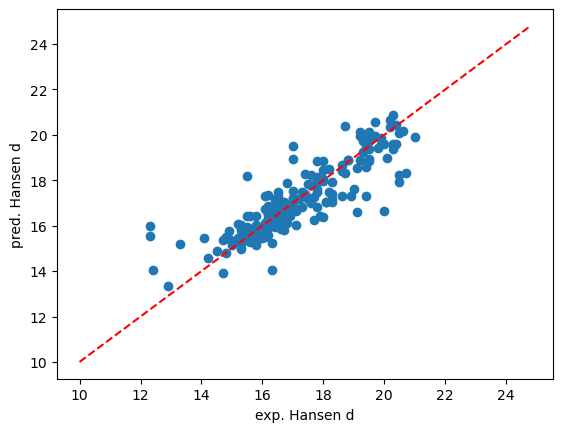

Fold:4, Train set: 986, Test set:197
MAE  : 0.6076
RMSE : 0.8339
R2   : 0.7820


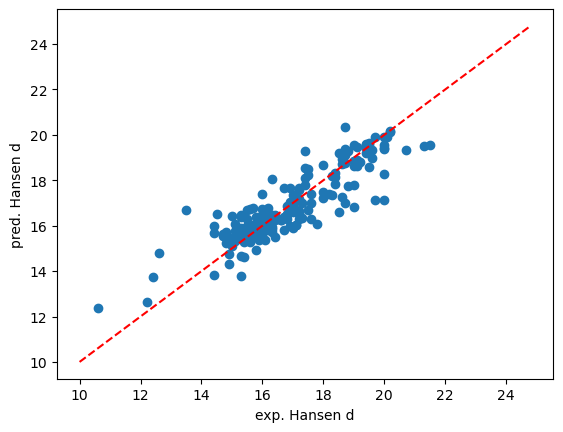

Fold:5, Train set: 986, Test set:197
MAE  : 0.6430
RMSE : 0.8614
R2   : 0.7937


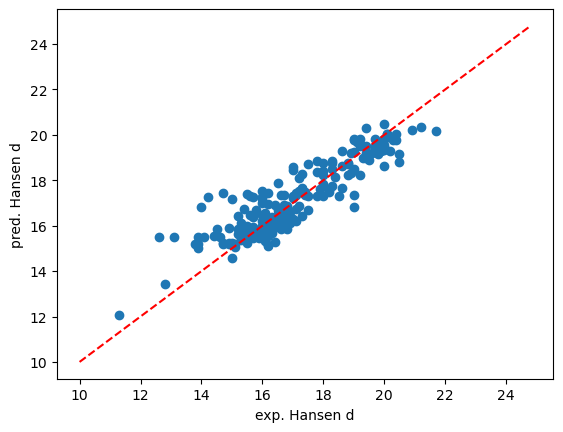

Fold:6, Train set: 986, Test set:197
MAE  : 0.6775
RMSE : 1.0009
R2   : 0.7077


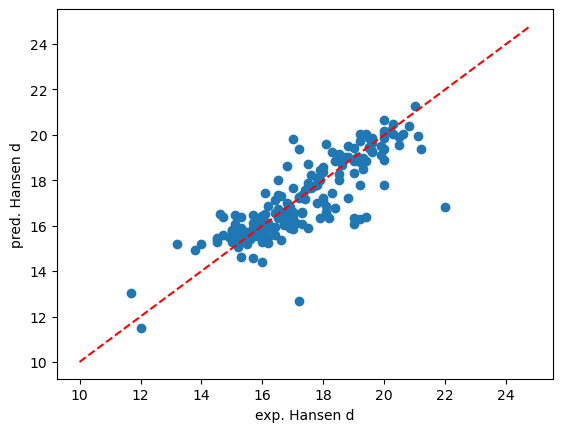


=== 6-Fold CV Summary (Mean ± Std) ===
MAE  : 0.6387 ± 0.0301
RMSE : 0.8991 ± 0.0666
R2   : 0.7459 ± 0.0427


In [6]:
import numpy as np
import pandas as pd
import math
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt

kf = KFold(n_splits=6, shuffle=True, random_state=42)

# store metrics for mean ± std
mae_scores = []
rmse_scores = []
r2_scores = []

cnt = 1

for train_index, test_index in kf.split(np_fps, hansen_d):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')

    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    hansen_train, hansen_test = hansen_d[train_index], hansen_d[test_index]
    index_test = mol_number[test_index]
    smiles_test = mol_smiles[test_index]

    # train + predict
    model = XGBRegressor()
    model.fit(fps_train, hansen_train)
    hansen_pred = model.predict(fps_test)

    # metrics for Hansen_d Kfolds
    fold_mae = mean_absolute_error(hansen_test, hansen_pred)
    fold_rmse = math.sqrt(mean_squared_error(hansen_test, hansen_pred))
    fold_r2 = r2_score(hansen_test, hansen_pred)

    # save metrics
    mae_scores.append(fold_mae)
    rmse_scores.append(fold_rmse)
    r2_scores.append(fold_r2)

    # print fold metrics
    print(f"MAE  : {fold_mae:.4f}")
    print(f"RMSE : {fold_rmse:.4f}")
    print(f"R2   : {fold_r2:.4f}")

    # save predictions for this fold
    pd_hansen_pred = pd.DataFrame(hansen_pred, columns=["predict"])
    out_df = pd.DataFrame({
        "Mol_No": index_test,
        "SMILES": smiles_test,
        "actual": hansen_test,
        "predict": hansen_pred
    })
    out_df.to_csv(f'fps_xgboost_hansen_d_fold_{cnt}.csv', index=False)

    # plot exp vs predicted values (optional)
    ln = np.arange(10, 25, 0.2)
    plt.plot(ln, ln, 'r--')
    plt.scatter(hansen_test, hansen_pred)
    plt.xlabel('exp. Hansen d')
    plt.ylabel('pred. Hansen d')
    plt.show()

    cnt += 1

# after CV: mean ± std
mae_scores = np.array(mae_scores)
rmse_scores = np.array(rmse_scores)
r2_scores = np.array(r2_scores)

print("\n=== 6-Fold CV Summary (Mean ± Std) ===")
print(f"MAE  : {mae_scores.mean():.4f} ± {mae_scores.std(ddof=1):.4f}")
print(f"RMSE : {rmse_scores.mean():.4f} ± {rmse_scores.std(ddof=1):.4f}")
print(f"R2   : {r2_scores.mean():.4f} ± {r2_scores.std(ddof=1):.4f}")

Fold:1, Train set: 985, Test set:198
0.6141498267048539
0.8444573994432952
0.7601840506936132


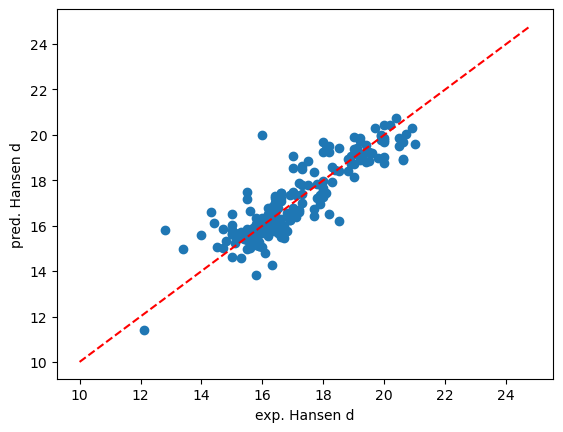

Fold:2, Train set: 986, Test set:197
0.6711366450120954
0.9554916129807636
0.6837074688325305


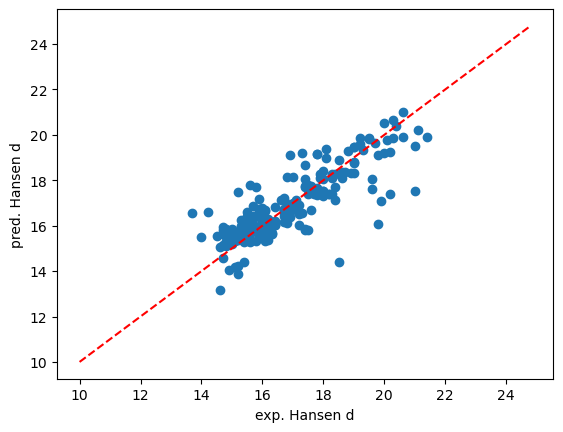

Fold:3, Train set: 986, Test set:197
0.6189478065761818
0.8982593118177059
0.7478690665713005


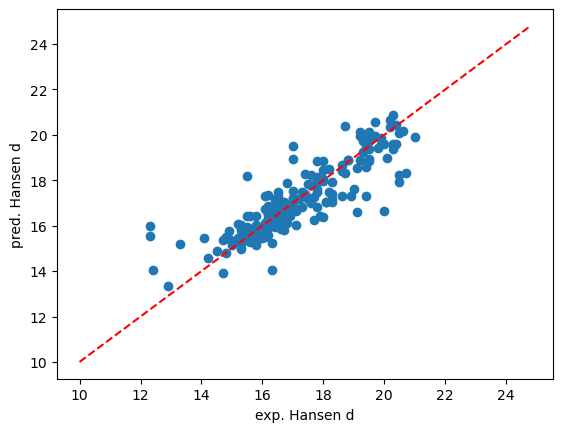

Fold:4, Train set: 986, Test set:197
0.6075565212269122
0.8338631434070374
0.782020839290724


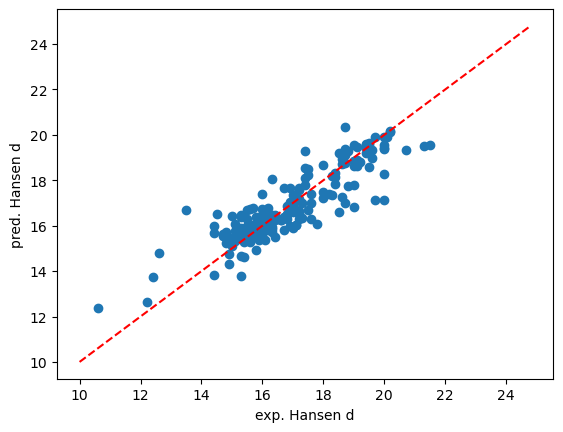

Fold:5, Train set: 986, Test set:197
0.6430154761687147
0.861429027373711
0.7937404548790329


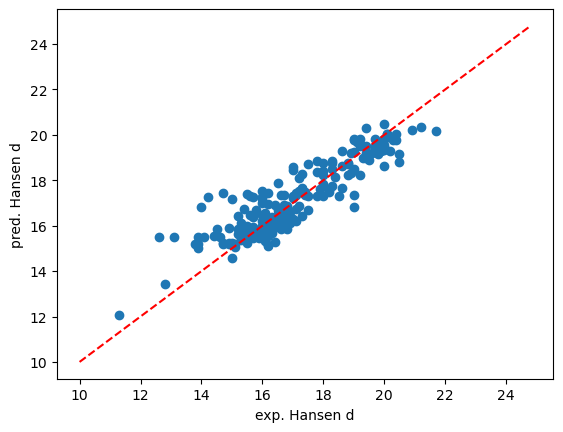

Fold:6, Train set: 986, Test set:197
0.6774962720532102
1.0009082979678303
0.7076940081114852


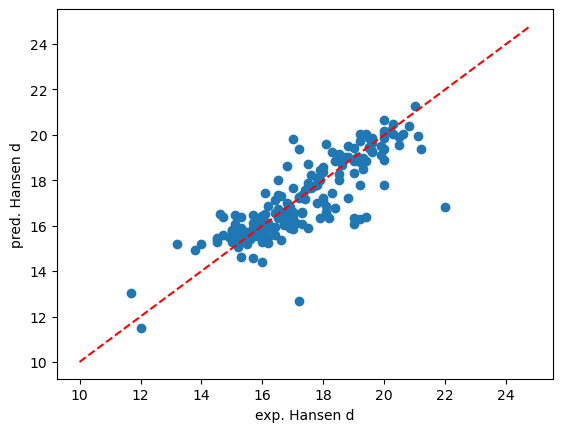

In [7]:
# split the data into 6 folds.  
# use'kf'(KFold splitting stratergy) object as input to cross_val_score() method
kf =KFold(n_splits=6, shuffle=True, random_state=42)

# initial fold number
cnt = 1

# split()  method generate indices to split data into training and test set.
for train_index, test_index in kf.split(np_fps, hansen_d):
    print(f'Fold:{cnt}, Train set: {len(train_index)}, Test set:{len(test_index)}')
    fps_train, fps_test = np_fps[train_index], np_fps[test_index]
    hansen_train, hansen_test = hansen_d[train_index], hansen_d[test_index]
    index_train, index_test = mol_number[train_index], mol_number[test_index]
    smiles_train, smiles_test = mol_smiles[train_index], mol_smiles[test_index]
    
    # training model
    model = XGBRegressor().fit(fps_train, hansen_train)
    hansen_pred = model.predict(fps_test)
    
    # print MAE, RMSE and R2
    print(mean_absolute_error (hansen_test, hansen_pred))
    print(math.sqrt(mean_squared_error(hansen_test, hansen_pred)))
    print(r2_score (hansen_test, hansen_pred))

    # convert predictions into df and concat molecules' index, SMILES, exp and predicted values 
    # and save into a csv file for each fold
    pd_hansen_pred = pd.DataFrame(hansen_pred, columns=["pred"])
    xg_output = pd.concat((index_test.reset_index(), smiles_test.reset_index(), hansen_test.reset_index(), pd_hansen_pred), ignore_index=True, axis=1)
    xg_output.to_csv(f'fps_xgboost_hansen_d_fold_{cnt}.csv')

    # plot exp vs predicted values
    ln = np.arange(10, 25, 0.2)
    plt.plot(ln, ln,'r--')
    plt.scatter(hansen_test, hansen_pred)
    plt.plot(color='green')

    plt.xlabel('exp. Hansen d')
    plt.ylabel('pred. Hansen d')
    plt.show()
    
    cnt += 1
    

In [8]:
# load predicted values from the previous 6-fold cross-validation as df
fps_xgboost_d_1 = pd.read_csv('fps_xgboost_hansen_d_fold_1.csv')
fps_xgboost_d_2 = pd.read_csv('fps_xgboost_hansen_d_fold_2.csv')
fps_xgboost_d_3 = pd.read_csv('fps_xgboost_hansen_d_fold_3.csv')
fps_xgboost_d_4 = pd.read_csv('fps_xgboost_hansen_d_fold_4.csv')
fps_xgboost_d_5 = pd.read_csv('fps_xgboost_hansen_d_fold_5.csv')
fps_xgboost_d_6 = pd.read_csv('fps_xgboost_hansen_d_fold_6.csv')
# concat the data, rename columns (actual=experimentally determined value)
fps_xgboost = pd.concat((fps_xgboost_d_1, fps_xgboost_d_2, fps_xgboost_d_3, fps_xgboost_d_4, fps_xgboost_d_5, fps_xgboost_d_6),axis=0)
fps_xgboost = fps_xgboost.rename({'3': 'SMILES', '4':'Mol_No', '5': 'actual', '6':'predict'}, axis='columns')

In [9]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# True and predicted values
y_true = fps_xgboost['actual']
y_pred = fps_xgboost['predict']

# Metrics
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R2   : {r2:.4f}")

MAE  : 0.6387
RMSE : 0.9011
R2   : 0.7480


In [10]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
from rdkit.Chem.Draw import IPythonConsole
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
import math

In [11]:
# load predicted values from the previous 6-fold cross-validation as df
fps_xgboost_d_1 = pd.read_csv('fps_xgboost_hansen_d_fold_1.csv')
fps_xgboost_d_2 = pd.read_csv('fps_xgboost_hansen_d_fold_2.csv')
fps_xgboost_d_3 = pd.read_csv('fps_xgboost_hansen_d_fold_3.csv')
fps_xgboost_d_4 = pd.read_csv('fps_xgboost_hansen_d_fold_4.csv')
fps_xgboost_d_5 = pd.read_csv('fps_xgboost_hansen_d_fold_5.csv')
fps_xgboost_d_6 = pd.read_csv('fps_xgboost_hansen_d_fold_6.csv')
# concat the data, rename columns (actual=experimentally determined value)
fps_xgboost = pd.concat((fps_xgboost_d_1, fps_xgboost_d_2, fps_xgboost_d_3, fps_xgboost_d_4, fps_xgboost_d_5, fps_xgboost_d_6),axis=0)
fps_xgboost = fps_xgboost.rename({'3': 'SMILES', '4':'Mol_No', '5': 'actual', '6':'predict'}, axis='columns')

In [12]:
# MAE, AE and RMSE give an idea of the error distribution
print(mean_absolute_error(fps_xgboost['actual'], fps_xgboost['predict']))

#RMSEs
print(math.sqrt(mean_squared_error(fps_xgboost['actual'], fps_xgboost['predict'])))

# R^2 Coefficient of Determination
print(r2_score(fps_xgboost['actual'], fps_xgboost['predict']))

0.6386963136094675
0.9010776555228581
0.7479677475935909


In [13]:
len(fps_xgboost)

1183

In [14]:
# calculate the residual value for each molecule
fps_xgboost['residual']= fps_xgboost['predict']-fps_xgboost['actual']

In [15]:
# calculate standardised deviation of the residuals (sdr) of the dataset
# equations used: sdr = sqrt((sum((residual)**2))/(n-2))
sdr = np.sqrt((fps_xgboost['residual']**2).sum()/(len(fps_xgboost)-2))
sdr

np.float64(0.9018403113136573)

In [16]:
# calculate how many sdr each molecule's predicted value is away from the exp value 
fps_xgboost['std_residual'] = fps_xgboost['residual']/sdr
fps_xgboost['std_residual']

0      0.713547
1     -0.435653
2      0.033301
3      0.726337
4     -1.045969
         ...   
192   -0.648382
193   -0.176968
194    0.282628
195    0.476710
196   -0.199367
Name: std_residual, Length: 1183, dtype: float64

In [17]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 3
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
fps_xgboost_outliers

,Unnamed: 0,0,1,2,SMILES,Mol_No,actual,predict,residual,std_residual
122,122,723,724,723,C=O,723,12.8,15.800039,3.000039,3.326575
136,136,809,811,809,CN(C)CCOC(=O)COc1ccc(Cl)cc1,809,16.0,19.988123,3.988123,4.422205
1,1,3,3,3,BrC(Br)C(Br)Br,3,21.0,17.509556,-3.490444,-3.870357
3,3,12,12,12,CC(Br)Br,12,18.5,14.397128,-4.102872,-4.549444
64,64,367,367,367,N,367,13.7,16.563951,2.863951,3.175674
134,134,767,769,767,IC(=C)C=C,767,19.9,17.075445,-2.824555,-3.131990
135,135,768,770,768,IC(I)I,768,20.2,17.384329,-2.815671,-3.122139
167,167,964,966,964,[O-][O+]=O,964,19.8,16.073320,-3.726680,-4.132306
70,70,404,404,404,NC(=O)NC(N)=O,404,20.0,16.649237,-3.350763,-3.715473
81,81,457,457,457,FC(F)Cl,457,12.3,15.533244,3.233244,3.585162


In [18]:
# Set the default text font size
plt.rc('font', size=22)

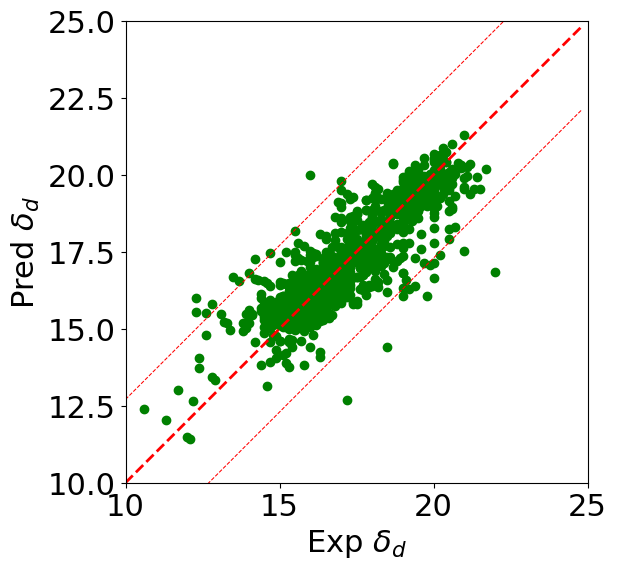

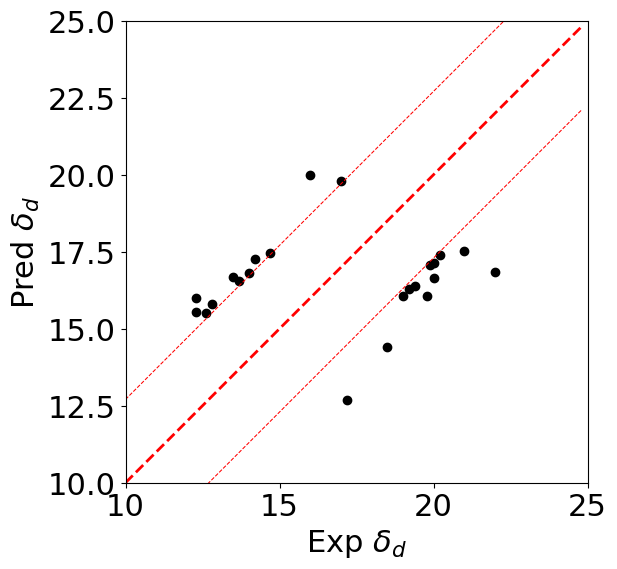

In [19]:
n = 3  # residual threshold

# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(10, 25, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln+n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln-n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')

plt.xlabel(r'Exp $\delta_d$')
plt.ylabel(r'Pred $\delta_d$')

plt.xlim([10,25])
plt.ylim([10,25])

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_hansen_d_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln+n*sdr, 'r--', linewidth=0.75)
plt.plot(ln, ln-n*sdr, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'], 
            y=fps_xgboost_outliers['predict'], 
            color='black')

plt.xlabel(r'Exp $\delta_d$')
plt.ylabel(r'Pred $\delta_d$')

plt.xlim([10,25])
plt.ylim([10,25])

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_hansen_d_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

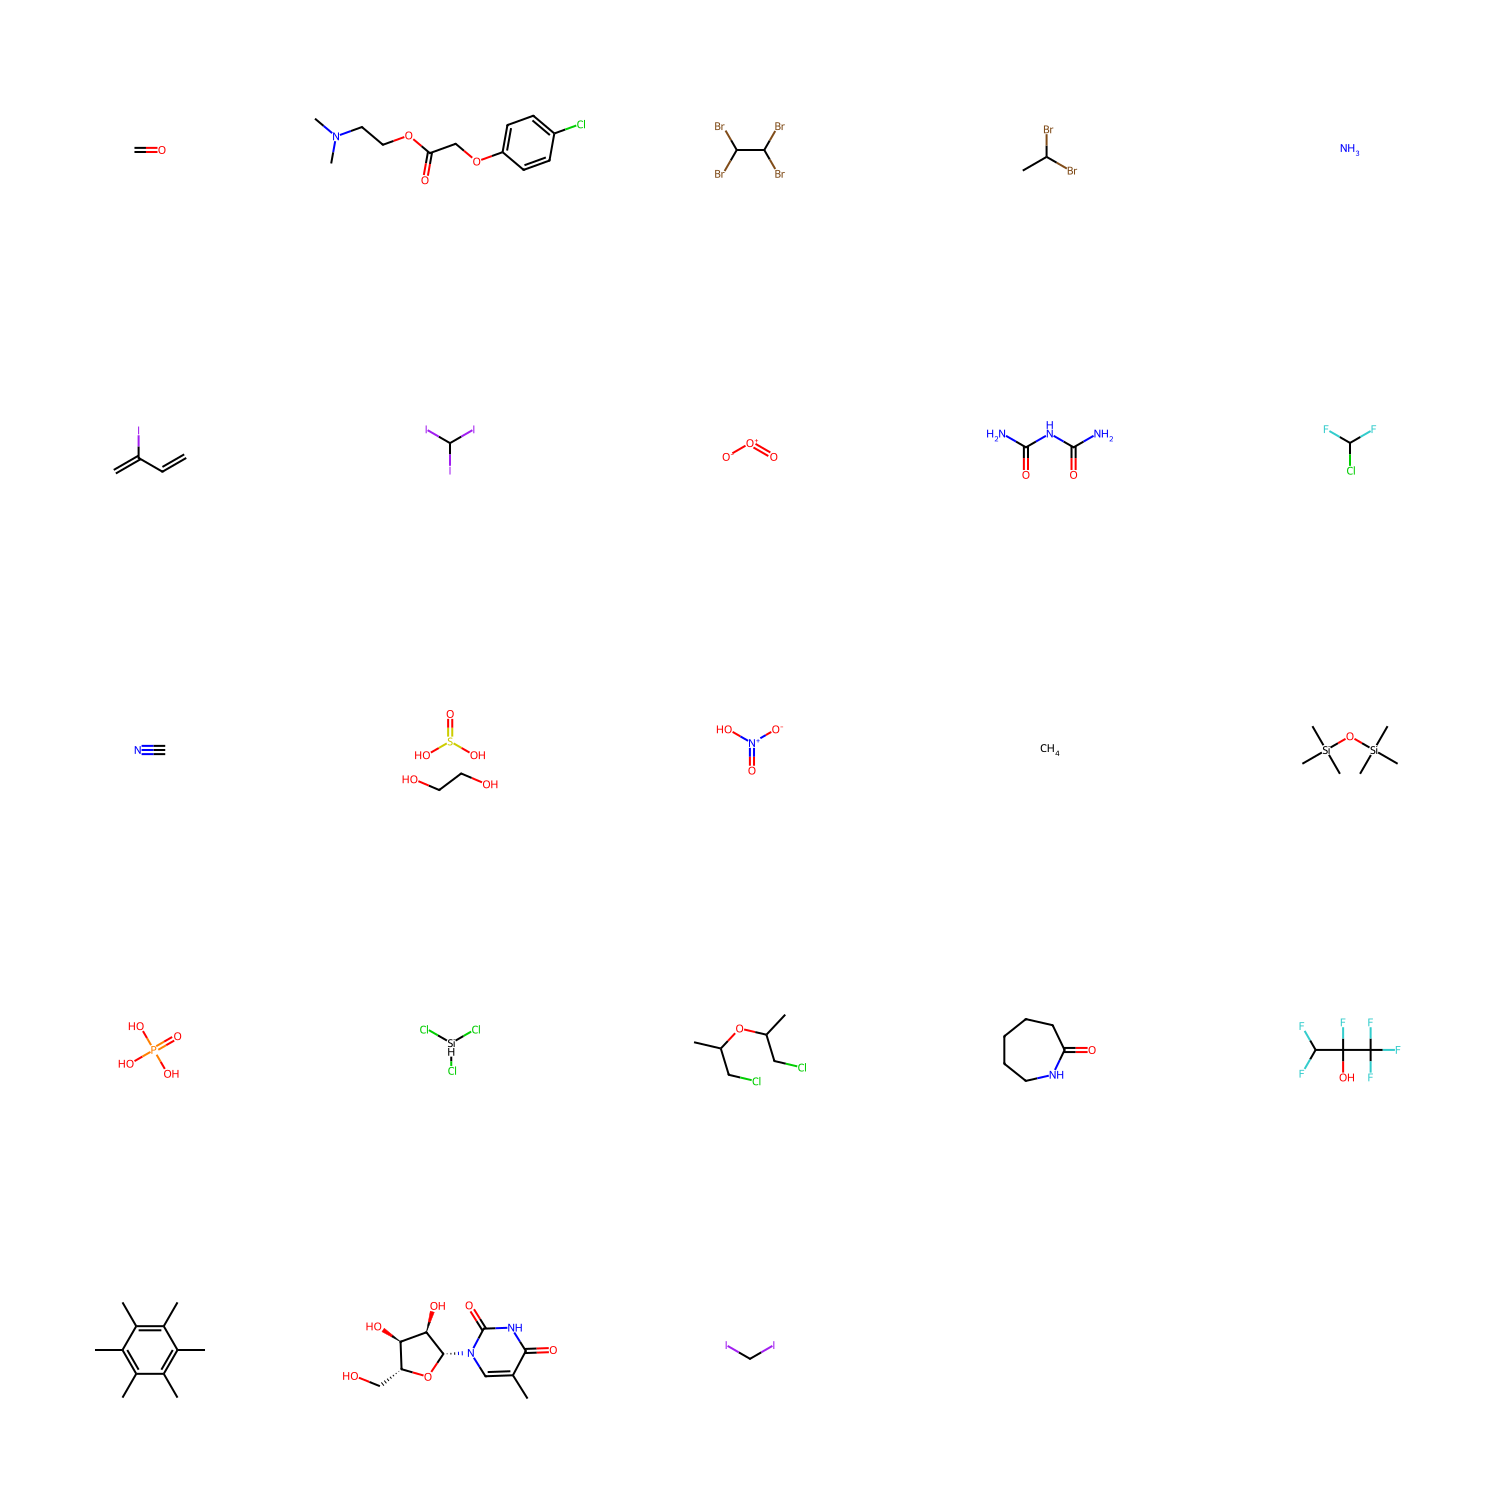

In [20]:
# draw n=3 outlier structure
outliners = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers['SMILES']]
Draw.MolsToGridImage(outliners, subImgSize=(300,300), molsPerRow=5, maxMols=50)

In [21]:
# n is 2 or 3. Points 2 or 3 sdr away from the prediction line are likely to be outliers
n = 2
fps_xgboost_outliers2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
len(fps_xgboost_outliers2)

65

In [22]:
fps_xgboost_outliers2

,Unnamed: 0,0,1,2,SMILES,Mol_No,actual,predict,residual,std_residual
6,6,54,54,54,FC(F)(F)c1cccc(c1)C(F)(F)F,54,17.0,19.069784,2.069784,2.295067
27,27,174,174,174,CC(C)Br,174,15.5,17.478480,1.978480,2.193825
72,72,415,415,415,FC(F)(F)Br,415,14.3,16.596914,2.296914,2.546919
93,93,551,551,551,FC(Cl)Cl,551,15.8,13.811938,-1.988062,-2.204450
96,96,557,557,557,CCOC(=O)CCCC(=O)OCC,557,16.3,14.247992,-2.052008,-2.275356
...,...,...,...,...,...,...,...,...,...,...
117,117,751,753,751,Cc1c(C)c(C)c(C)c(C)c1C,751,19.2,16.296818,-2.903182,-3.219175
120,120,769,771,769,IC(=C)C=C,769,17.2,19.381868,2.181868,2.419351
139,139,863,865,863,CC1=CN([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C(=O)...,863,17.0,19.801264,2.801264,3.106164
142,142,878,880,878,ICI,878,22.0,16.840494,-5.159506,-5.721086


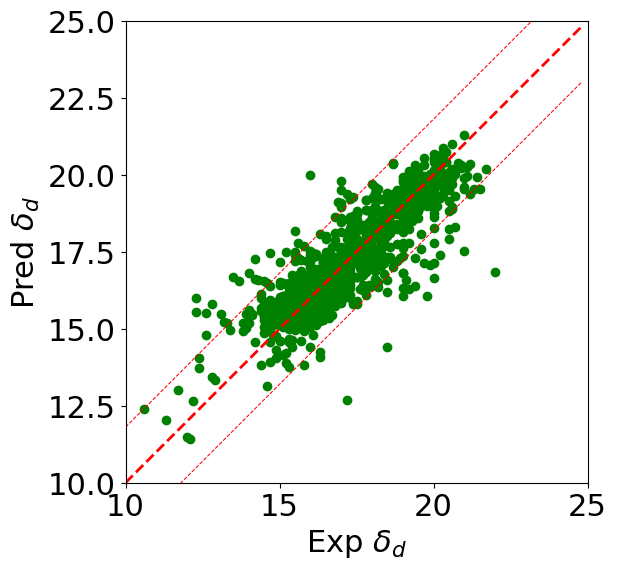

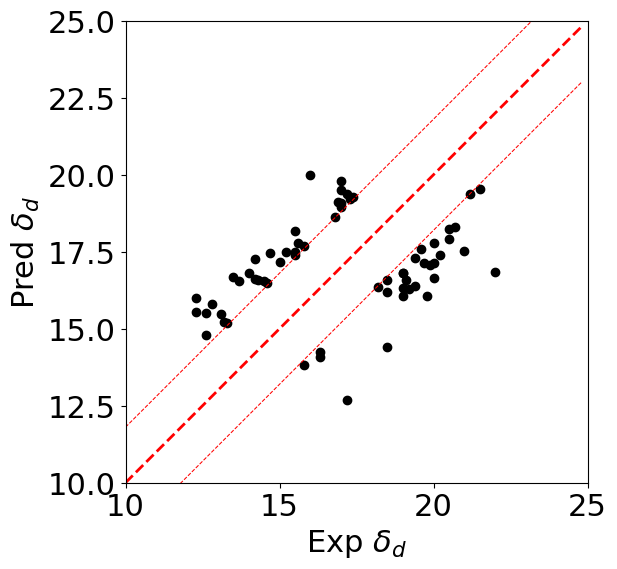

In [23]:
sdr_d = np.sqrt((fps_xgboost['residual']**2).sum() / (len(fps_xgboost) - 2))

fps_xgboost['std_residual'] = fps_xgboost['residual'] / sdr_d

n = 2
fps_xgboost_outliers = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]

# -------- Plot 1: all molecules --------
plt.figure(figsize=(6,6))

ln = np.arange(10, 25, 0.2)

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_d, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_d, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost['actual'], y=fps_xgboost['predict'], color='green')

plt.xlabel(r'Exp $\delta_d$')
plt.ylabel(r'Pred $\delta_d$')

plt.xlim([10,25])
plt.ylim([10,25])

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_hansen_d2_all_points.png", dpi=300, bbox_inches="tight")
plt.show()


# -------- Plot 2: outliers only --------
plt.figure(figsize=(6,6))

plt.plot(ln, ln, 'r--', linewidth=2)
plt.plot(ln, ln + n*sdr_d, 'r--', linewidth=0.75)
plt.plot(ln, ln - n*sdr_d, 'r--', linewidth=0.75)

plt.scatter(x=fps_xgboost_outliers['actual'],
            y=fps_xgboost_outliers['predict'],
            color='black')

plt.xlabel(r'Exp $\delta_d$')
plt.ylabel(r'Pred $\delta_d$')

plt.xlim([10,25])
plt.ylim([10,25])

plt.gca().set_aspect('equal', adjustable='box')

plt.savefig("xgboost_hansen_d2_outliers.png", dpi=300, bbox_inches="tight")
plt.show()

/opt/miniconda3/envs/my-rdkit-env/lib/python3.14/site-packages/rdkit/Chem/Draw/IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


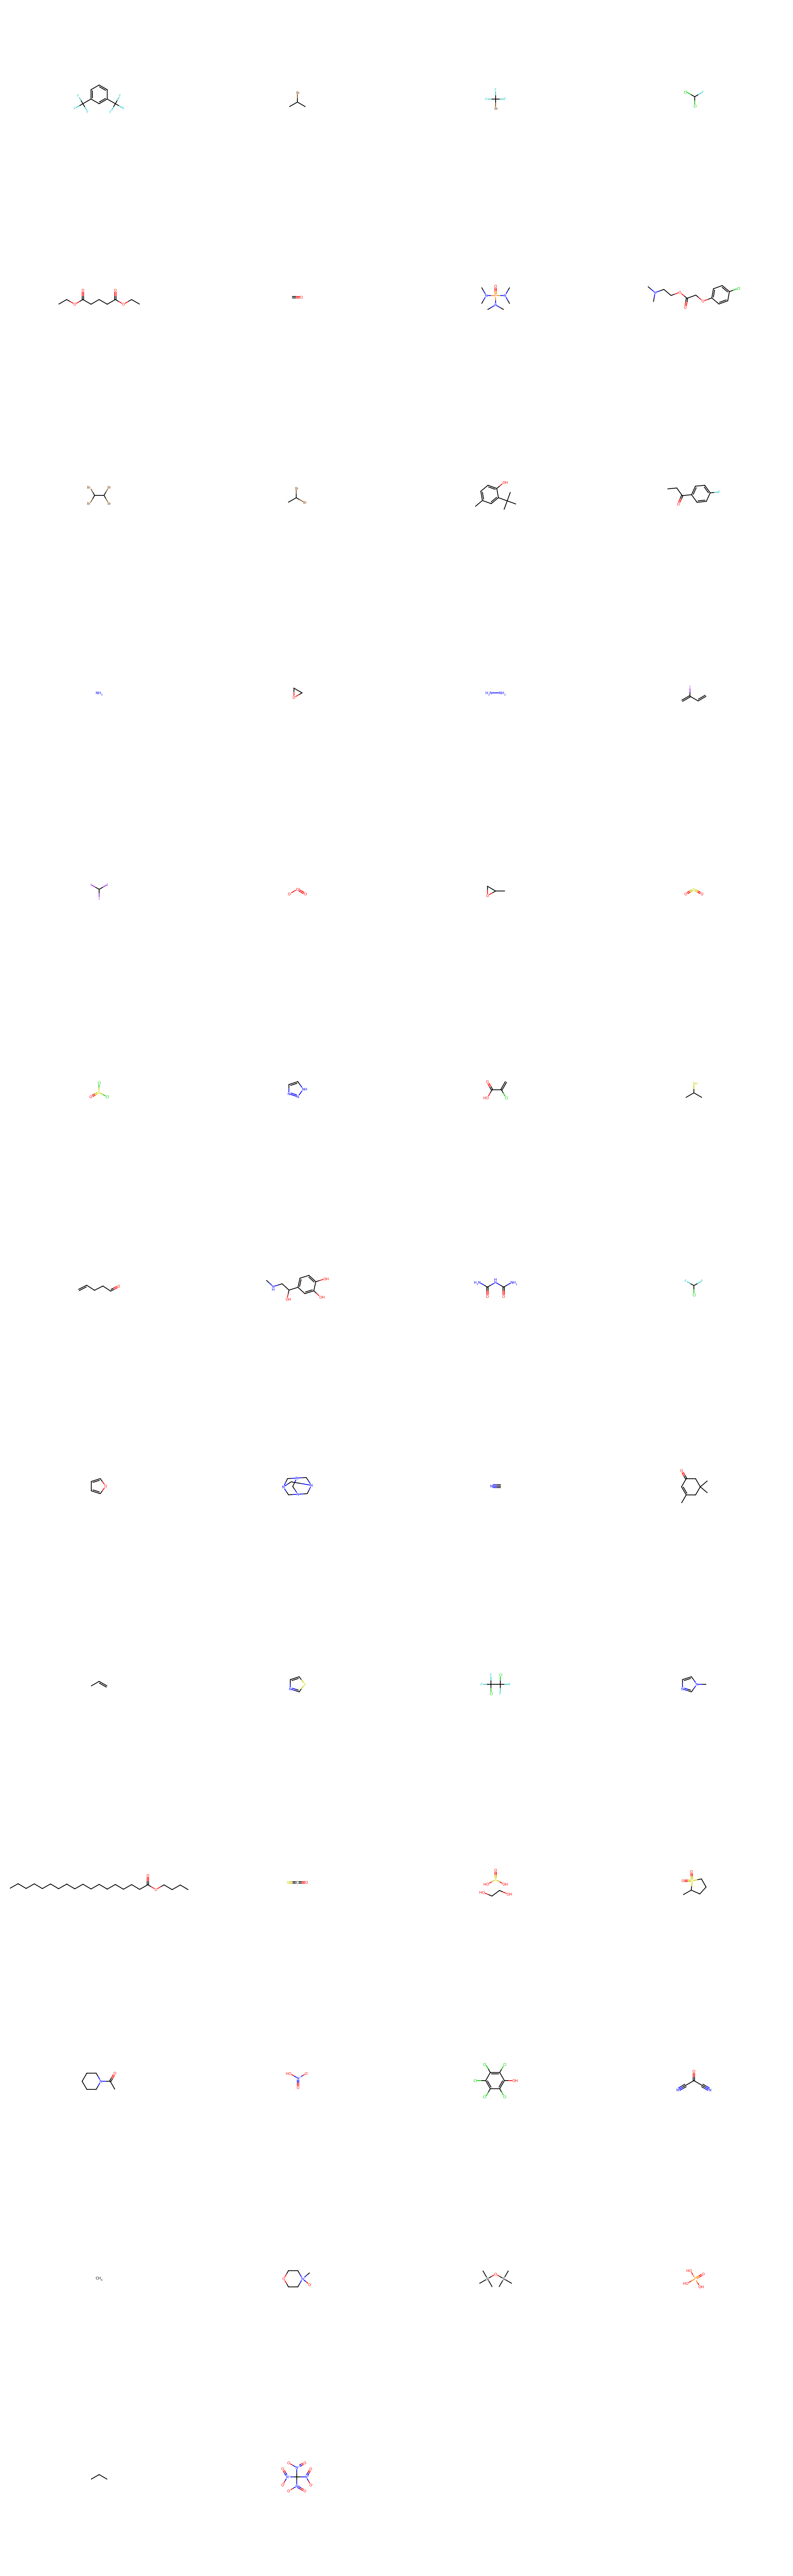

In [24]:
# draw n=2 outlier structure
outliners2 = [Chem.MolFromSmiles(x) for x in fps_xgboost_outliers2['SMILES']]
Draw.MolsToGridImage(outliners2, subImgSize=(500,500), molsPerRow=4)

In [25]:
# save outliers (n=2) info to a csv file
fps_xgboost_outliers2.to_csv('fps_xgboost_d_outliers2.csv')

In [26]:
from rdkit.Chem import Descriptors
gpHSP_data = pd.read_csv(r'/Users/favour/Desktop/untitled folder/dataset/hansen_1k_smiles_shorter.csv')
mol_smiles = gpHSP_data['SMILES']

# calculate molecular weight of the full dataset
molwt = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in gpHSP_data['SMILES']]
np_molwt = np.asarray(molwt)

# calculate molecular weight of outliers
molwt_outliers2 = [(Descriptors.ExactMolWt(Chem.MolFromSmiles(x))) for x in fps_xgboost_outliers2['SMILES']]
np_molwt_outliers2 = np.asarray(molwt_outliers2)

# Compare average molecular weight for full data and outliers
print(np.average(np_molwt))
print(np.average(np_molwt_outliers2))

131.2953603288794
130.31859922360002


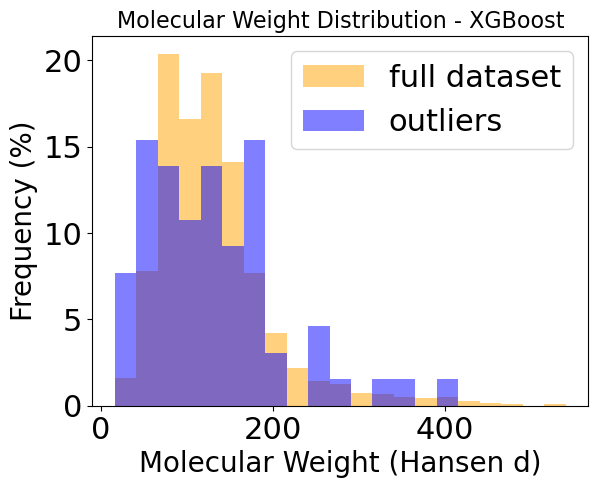

In [27]:
# plot molecular weight distribution for the full dataset and the outliers
bin_width = 25
df = pd.DataFrame(np_molwt, columns = ["full dataset"])
df2 = pd.DataFrame(np_molwt_outliers2, columns = ["outliers"])

ax = df.plot.hist(bins=(np.arange(min(molwt), max(molwt)+bin_width, bin_width)), alpha=0.5, color='orange', weights=np.ones_like(df.index) *100/ len(df))
df2.plot(kind='hist', bins=(np.arange(min(molwt_outliers2), max(molwt_outliers2)+bin_width, bin_width)), alpha=0.5, color='blue', weights=np.ones_like(df2.index) *100 /len(df2), ax=ax)
ax.set_xlabel("Molecular Weight (Hansen d)", size=20)
ax.set_ylabel("Frequency (%)", size=20)
ax.set_title("Molecular Weight Distribution - XGBoost", size=16)
plt.show()

In [28]:
import openbabel
from openbabel import pybel
import csv,sys
import pandas as pd
import numpy as np

In [31]:
# The functional group distribution is analysed in a similar fashion as used by 
# S. Boobier, D. R. J. Hose, A. J. Blacker and B. N. Nguyen, Nat Commun, 2020, 11, 5753.
# https://doi.org/10.1038/s41467-020-19594-z
# the core code to count functional groups can be found in the ESI of the publication 

#get SMARTS and Dataset
#file with column called “FG” with list of FGs to analyse, and column called “SMARTS” of SMARTS codes
SMARTS1=pd.read_csv('/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv') 

In [32]:
SMARTS1['SMARTS']

0                                           [F,Cl,Br,I]
1                                                   [F]
2                                                  [Cl]
3                                                  [Br]
4                                                   [I]
5                                           [CX3]=[OX1]
6                                     [#6][CX3](=O)[#6]
7                                       [CX3H1](=O)[#6]
8                                [NX3][CX3](=[OX1])[#6]
9                              [#6][CX3](=O)[OX2H0][#6]
10                                     [CX3](=O)[OX2H1]
11    [$([cX3](:*):*),$([cX2+](:*):*),$([CX3]=*),$([...
12                                         [$([CX2]#C)]
13                     [$([cX3](:*):*),$([cX2+](:*):*)]
14                                          [NX1]#[CX2]
15                                 [NX3;H2,H1;!$(NC=O)]
16              [$([NX3](=O)=O),$([NX3+](=O)[O-])][!#8]
17                                          [NX2

In [33]:
# get SMARTS and dataset
SMARTS1 = pd.read_csv('/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv')

fg_names = list(SMARTS1["FG"])
smarts_codes = list(SMARTS1["SMARTS"])

In [34]:
def detect_fgs(smiles_series, id_series, SMARTS1):
    fg_names = list(SMARTS1["FG"])
    smarts_codes = list(SMARTS1["SMARTS"])

    rows = []

    for mol_id, smi in zip(id_series, smiles_series):
        row = {"Mol_No": mol_id}

        try:
            mol = pybel.readstring("smi", smi)
        except:
            for fg in fg_names:
                row[fg] = np.nan
            rows.append(row)
            continue

        for fg, smarts_code in zip(fg_names, smarts_codes):
            try:
                smarts = pybel.Smarts(smarts_code)
                row[fg] = 1 if smarts.findall(mol) else 0
            except:
                row[fg] = np.nan

        rows.append(row)

    return pd.DataFrame(rows)

In [35]:
fg_all = detect_fgs(
    smiles_series=fps_xgboost["SMILES"],
    id_series=fps_xgboost["Mol_No"],
    SMARTS1=SMARTS1
)

In [36]:
fg_outliers = detect_fgs(
    smiles_series=fps_xgboost_outliers["SMILES"],
    id_series=fps_xgboost_outliers["Mol_No"],
    SMARTS1=SMARTS1
)

In [37]:
fg_names = list(SMARTS1["FG"])

overall_freq = fg_all[fg_names].mean()
outlier_freq = fg_outliers[fg_names].mean()

fg_summary = pd.DataFrame({
    "overall_freq": overall_freq,
    "outlier_freq": outlier_freq
})

fg_summary["difference"] = fg_summary["outlier_freq"] - fg_summary["overall_freq"]
fg_summary["enrichment_ratio"] = fg_summary["outlier_freq"] / fg_summary["overall_freq"]

fg_summary = fg_summary.sort_values("difference", ascending=False)

print(fg_summary)

                  overall_freq  outlier_freq  difference  enrichment_ratio
Halides               0.252747      0.323077    0.070330          1.278261
F                     0.047337      0.107692    0.060355          2.275000
I                     0.007608      0.061538    0.053931          8.088889
S                     0.065934      0.107692    0.041758          1.633333
Br                    0.040575      0.076923    0.036348          1.895833
Acidic hydroxyl       0.043956      0.076923    0.032967          1.750000
Amide                 0.024514      0.046154    0.021640          1.882759
P                     0.011834      0.030769    0.018935          2.600000
Thiol                 0.011834      0.015385    0.003550          1.300000
Sulfonamide           0.001691      0.000000   -0.001691          0.000000
Azo                   0.001691      0.000000   -0.001691          0.000000
Thioamide             0.002536      0.000000   -0.002536          0.000000
Ketone                0.0

In [41]:
SMARTS1 = pd.read_csv(
    "/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv"
)

In [42]:
FG_names = SMARTS1["FG"]
SMARTS_codes = SMARTS1["SMARTS"]

In [43]:
fps_xgboost_outliers

,Unnamed: 0,0,1,2,SMILES,Mol_No,actual,predict,residual,std_residual
6,6,54,54,54,FC(F)(F)c1cccc(c1)C(F)(F)F,54,17.0,19.069784,2.069784,2.295067
27,27,174,174,174,CC(C)Br,174,15.5,17.478480,1.978480,2.193825
72,72,415,415,415,FC(F)(F)Br,415,14.3,16.596914,2.296914,2.546919
93,93,551,551,551,FC(Cl)Cl,551,15.8,13.811938,-1.988062,-2.204450
96,96,557,557,557,CCOC(=O)CCCC(=O)OCC,557,16.3,14.247992,-2.052008,-2.275356
...,...,...,...,...,...,...,...,...,...,...
117,117,751,753,751,Cc1c(C)c(C)c(C)c(C)c1C,751,19.2,16.296818,-2.903182,-3.219175
120,120,769,771,769,IC(=C)C=C,769,17.2,19.381868,2.181868,2.419351
139,139,863,865,863,CC1=CN([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)C(=O)...,863,17.0,19.801264,2.801264,3.106164
142,142,878,880,878,ICI,878,22.0,16.840494,-5.159506,-5.721086


In [45]:
print(fps_xgboost_outliers.columns)

Index(['Unnamed: 0', '0', '1', '2', 'SMILES', 'Mol_No', 'actual', 'predict',
       'residual', 'std_residual'],
      dtype='str')


In [47]:
import pandas as pd
import numpy as np
from openbabel import pybel

SMARTS1 = pd.read_csv(
    "/Users/favour/Desktop/untitled folder/outliers_functional_groups_analysis/SMARTS.csv"
)

FG_names = SMARTS1["FG"]
SMARTS_codes = SMARTS1["SMARTS"]

smiles = fps_xgboost_outliers["SMILES"]
ids = fps_xgboost_outliers["Mol_No"]

In [48]:
FG_list = []

for f in range(len(fps_xgboost_outliers)):
    FG = []
    FG.append(ids.iloc[f])

    mol = pybel.readstring("smi", smiles.iloc[f])

    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")

    FG_list.append(FG)

In [49]:
FG_names2 = list(FG_names)
FG_names2.insert(0, "Mol_No")

FG_list = pd.DataFrame(FG_list, columns=FG_names2)

FG_list.to_csv("FG_hansen_d_fps_xgboost_outliers.csv", index=False)

FG_list.head()

,Mol_No,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,54,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,174,1,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,415,1,1,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,551,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,557,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1


In [51]:
smiles_all = fps_xgboost["SMILES"]
ids_all = fps_xgboost["Mol_No"]

In [52]:
FG_list_all = []

for f in range(len(fps_xgboost)):
    FG = []
    FG.append(ids_all.iloc[f])

    mol = pybel.readstring("smi", smiles_all.iloc[f])

    for g in SMARTS_codes:
        smarts = pybel.Smarts(g)
        if smarts.findall(mol) == []:
            FG.append("0")
        else:
            FG.append("1")

    FG_list_all.append(FG)

In [53]:
FG_names2 = list(FG_names)
FG_names2.insert(0, "Mol_No")

FG_list_all = pd.DataFrame(FG_list_all, columns=FG_names2)

FG_list_all.to_csv("FG_hansen_d_fps_xgboost_all.csv", index=False)

FG_list_all.head()

,Mol_No,Halides,F,Cl,Br,I,Carbonyl,Ketone,Aldehyde,Amide,...,Alcohol,Ether inc. ester,P,S,Thiol,Thioamide,Sulfonamide,H-bond donor,Acidic hydroxyl,H-bond acceptor
0,10,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
1,23,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,31,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,44,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,49,0,0,0,0,0,0,0,0,0,...,0,0,0,1,1,0,0,1,0,1


In [54]:
import pandas as pd

fg_all = pd.read_csv("FG_hansen_d_fps_xgboost_all.csv")
fg_out = pd.read_csv("FG_hansen_d_fps_xgboost_outliers.csv")

In [47]:
import sys
!{sys.executable} -m pip install pyarrow

In [48]:
# n = 2 outliers
n = 2
fps_xgboost_outliers_n2 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n2 = len(fps_xgboost_outliers_n2)

print("Number of outliers at n = 2:", num_outliers_n2)

# n = 3 outliers
n = 3
fps_xgboost_outliers_n3 = fps_xgboost.loc[abs(fps_xgboost['std_residual']) > n]
num_outliers_n3 = len(fps_xgboost_outliers_n3)

print("Number of outliers at n = 3:", num_outliers_n3)

Number of outliers at n = 2: 65
Number of outliers at n = 3: 23
